# 09 — Village Point → Raster Spatial Interpolation
## IDW Resolution Experiment, Thailand Mask, Zonal Statistics & Method Comparison

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Intermediate  
**ข้อมูล:** Thailand Village Points + ADM1 Provinces  
**เครื่องมือ:** GeoPandas · SciPy · Rasterio · Matplotlib · Folium

Notebook นี้เป็นการเปลี่ยนจาก **Vector GIS → Raster GIS**

คำถามหลักมี 3 ข้อ:

1. Point data สามารถสร้าง continuous raster surface ได้อย่างไร?
2. Raster resolution 10, 20, 50 และ 100 km ทำให้ผลเปลี่ยนอย่างไร?
3. เมื่อใช้ grid เดียวกัน 50 km วิธี IDW, Thin Plate Spline และ Trend Surface ให้ผลต่างกันอย่างไร?

แกนของบท:

$$
\boxed{
Village\ Points
\rightarrow
Local\ Point\ Metric
\rightarrow
Interpolation
\rightarrow
Raster
\rightarrow
Thailand\ Mask
\rightarrow
Zonal\ Statistics
\rightarrow
Comparison
}
$$

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบายความต่างระหว่าง Vector Point และ Raster
2. อธิบายว่าการ interpolate ต้องมี numeric attribute ที่แต่ละ point
3. สร้าง local village-point density ที่ village points
4. อธิบายความต่างระหว่าง cell size และ search radius
5. สร้าง IDW raster ที่ 10, 20, 50 และ 100 km
6. ใช้ shared color scale เพื่อเปรียบเทียบ raster อย่างเป็นธรรม
7. Mask raster ให้เหลือเฉพาะประเทศไทย
8. ทำ zonal statistics จาก raster → Province
9. สร้าง provincial choropleth และ Folium layer comparison
10. เปรียบเทียบ IDW, Thin Plate Spline และ Trend Surface ที่ grid 50 km
11. อธิบายว่าแผนที่ที่ smooth กว่าไม่ได้แปลว่าแม่นยำกว่า

## Recap จาก Notebooks 06–08

ที่ผ่านมาเราใช้ village points เพื่อ

```text
06 → Spatial Join → Count / Density
07 → Distance → Buffer / Ring
08 → Clip / Overlay → Spatial Statistics
```

Notebook 09 จะเปลี่ยน representation:

$$
Point
\rightarrow
Continuous\ Raster\ Surface
$$

## คำถามเปิดบท

สมมติเรามี village points กระจายทั่วประเทศ

```text
•      •
   •
       •      •
```

เราต้องการสร้าง raster:

```text
┌────┬────┬────┐
│ z  │ z  │ z  │
├────┼────┼────┤
│ z  │ z  │ z  │
├────┼────┼────┤
│ z  │ z  │ z  │
└────┴────┴────┘
```

แต่ก่อน interpolate ต้องตอบให้ได้ว่า

> ค่า $z$ ที่แต่ละ village point คืออะไร?

## ทำไมจึงไม่ควรให้ village ทุกจุดมีค่า = 1 แล้ว interpolate?

IDW:

$$
\hat z(x_0)
=
\frac{
\sum_i w_i z_i
}{
\sum_i w_i
}
$$

ถ้า

$$
z_i=1
\quad \forall i
$$

จะได้

$$
\hat z(x_0)=1
$$

ในบริเวณที่มีข้อมูลรองรับ

ดังนั้น “ตำแหน่ง” อย่างเดียวไม่เพียงพอสำหรับ interpolation

$$
\boxed{
Point
+
Numeric\ Attribute
\rightarrow
Interpolation
}
$$

## ตัวแปรต้นทางของบทนี้: Local Village-point Density

สำหรับ village point $i$ เรานับจำนวน village records ภายในรัศมี 20 km แล้วคำนวณ

$$
D_i(20)
=
\frac{
N_i(20)-1
}{
\pi(20)^2
}
$$

หน่วย:

$$
villages/km^2
$$

`-1` ใช้ตัดตัว point เองออกจาก neighbor count

> ตัวแปรนี้คือ **local village-point density** ไม่ใช่ population density และไม่ใช่ Kernel Density Estimation (KDE)

# Part A — Setup & Source Data

## 1. ติดตั้ง libraries

In [1]:
%pip -q install geopandas rasterio scipy folium xyzservices pyogrio

In [2]:
from pathlib import Path
import shutil
import zipfile
import json
import warnings

import requests
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from scipy.spatial import cKDTree
from scipy.interpolate import RBFInterpolator

import rasterio
from rasterio.transform import from_origin
from rasterio.features import geometry_mask
from shapely.geometry import mapping

import folium
import xyzservices.providers as xyz

from IPython.display import display

print("GeoPandas:", gpd.__version__)
print("Pandas   :", pd.__version__)
print("Rasterio :", rasterio.__version__)
print("Folium   :", folium.__version__)

# ---------------------------------------------

FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

# ---------------------------------------------

DATA_DIR = Path("/content/gis09_data")
OUTPUT_DIR = Path("/content/gis09_outputs")

RASTER_DIR = OUTPUT_DIR / "rasters"
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [
    DATA_DIR,
    OUTPUT_DIR,
    RASTER_DIR,
    MAP_DIR,
    VECTOR_DIR,
    TABLE_DIR,
    HTML_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

GeoPandas: 1.2.0
Pandas   : 2.2.3
Rasterio : 1.5.2
Folium   : 0.20.0
Thai font ready: Sarabun


## 4. Helpers สำหรับ download และ field detection

In [3]:
def download_and_extract_zip(
    url,
    zip_name,
    extract_name
):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(
            url,
            timeout=120
        )
        response.raise_for_status()
        zip_path.write_bytes(
            response.content
        )

    if extract_dir.exists():
        shutil.rmtree(
            extract_dir
        )

    extract_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:
        z.extractall(
            extract_dir
        )

    shp_files = list(
        extract_dir.rglob("*.shp")
    )

    if not shp_files:
        raise FileNotFoundError(
            f"ไม่พบ .shp ใน {zip_name}"
        )

    return shp_files[0]


def find_column(
    gdf,
    candidates,
    required=False
):
    lookup = {
        str(c).upper(): c
        for c in gdf.columns
    }

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field: "
            + ", ".join(candidates)
        )

    return None

## 5. Load Village + ADM1

## 6. Confirm schema จริง

## 7. CRS / geometry QC

In [4]:
BASE = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/main"
)

village_shp = download_and_extract_zip(
    f"{BASE}/village/TH_VILLAGE2012.zip",
    "TH_VILLAGE2012.zip",
    "village"
)

adm1_shp = download_and_extract_zip(
    f"{BASE}/tha_adm1/tha_adm1_province_shapefile.zip",
    "tha_adm1_province_shapefile.zip",
    "adm1"
)

village = gpd.read_file(
    village_shp,
    encoding="UTF-8"
)

province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)

print("Village features:", len(village))
print("Province features:", len(province))
print("Village CRS:", village.crs)
print("Province CRS:", province.crs)

# ---------------------------------------------

NAME_FIELD = find_column(
    village,
    ["NAME", "VILL_NAME", "VILLAGE"],
    required=True
)

TAMBON_FIELD = find_column(
    village,
    ["TAM_NAME", "TAMBON", "ADM3_TH"],
    required=True
)

DISTRICT_FIELD = find_column(
    village,
    ["AMP_NAME", "AMPHOE", "ADM2_TH"],
    required=True
)

PROVINCE_FIELD = find_column(
    village,
    ["PRV_NAME", "PROVINCE", "ADM1_TH"],
    required=True
)

P_CODE = find_column(
    province,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

P_NAME = find_column(
    province,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

display(
    village[
        [
            NAME_FIELD,
            TAMBON_FIELD,
            DISTRICT_FIELD,
            PROVINCE_FIELD,
            "geometry"
        ]
    ].head(10)
)

# ---------------------------------------------

qc = pd.DataFrame({
    "Village": [
        len(village),
        village.geometry.isna().sum(),
        village.geometry.is_empty.sum()
    ],
    "Province": [
        len(province),
        province.geometry.isna().sum(),
        province.geometry.is_empty.sum()
    ]
}, index=[
    "Features",
    "Missing geometry",
    "Empty geometry"
])

display(qc)

Village features: 65213
Province features: 77
Village CRS: EPSG:4326
Province CRS: EPSG:4326


,NAME,TAM_NAME,AMP_NAME,PRV_NAME,geometry
0,บ้านท่าลานเตียน,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11985 15.41106)
1,บ้านหนองสะแก,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11425 15.40837)
2,บ้านหัวยาง,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11983 15.40744)
3,บ้านสะพานหิน,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.10213 15.40663)
4,บ้านทุ่งประพาส,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.09463 15.39853)
5,บ้านหางน้ำหนองแขม,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.14494 15.39737)
6,บ้านหลั่น,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11045 15.39574)
7,บ้านหางน้ำหนองแขม,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.14024 15.39016)
8,ท่าฉนวน,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.10948 15.38761)
9,บ้านทุ่งใหญ่,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.10481 15.38582)


,Village,Province
Features,65213,77
Missing geometry,0,0
Empty geometry,0,0


# Part B — Create a Numeric Variable at Village Points

## 8. Reproject to EPSG:32647

ระยะทางและ grid size ในบทนี้ใช้หน่วย meter

เราจะใช้ EPSG:32647 เพื่อให้ต่อเนื่องกับ course ก่อนหน้า

> เป็น practical teaching projection ไม่ใช่การอ้างว่าเป็น projection ที่ดีที่สุดสำหรับ nationwide analysis ทุกกรณี

In [5]:
village_utm = village.to_crs(
    "EPSG:32647"
)

province_utm = province.to_crs(
    "EPSG:32647"
)

coords = np.column_stack([
    village_utm.geometry.x,
    village_utm.geometry.y
])

print("Village points:", len(coords))

# ---------------------------------------------

tree = cKDTree(
    coords
)

LOCAL_RADIUS_M = 20_000

neighbor_count_including_self = (
    tree.query_ball_point(
        coords,
        r=LOCAL_RADIUS_M,
        return_length=True
    )
)

neighbor_count = (
    neighbor_count_including_self
    - 1
)

print(
    "Neighbor count range:",
    neighbor_count.min(),
    "to",
    neighbor_count.max()
)

# ---------------------------------------------

LOCAL_RADIUS_KM = (
    LOCAL_RADIUS_M
    / 1000
)

neighborhood_area_km2 = (
    np.pi
    * LOCAL_RADIUS_KM**2
)

village_utm[
    "neighbor_20km"
] = neighbor_count

village_utm[
    "local_density"
] = (
    village_utm[
        "neighbor_20km"
    ]
    / neighborhood_area_km2
)

display(
    village_utm[
        [
            NAME_FIELD,
            TAMBON_FIELD,
            DISTRICT_FIELD,
            PROVINCE_FIELD,
            "neighbor_20km",
            "local_density"
        ]
    ]
    .sort_values(
        "local_density",
        ascending=False
    )
    .head(10)
    .round(4)
)

Village points: 65213
Neighbor count range: 0 to 899


,NAME,TAM_NAME,AMP_NAME,PRV_NAME,neighbor_20km,local_density
2063,บ้านมะขามเทศ,มหาพราหมณ์,บางบาล,พระนครศรีอยุธยา,899,0.7154
2057,บ้านมะขามเทศ,มหาพราหมณ์,บางบาล,พระนครศรีอยุธยา,898,0.7146
2080,บ้านคูมอญ,มหาพราหมณ์,บางบาล,พระนครศรีอยุธยา,898,0.7146
2014,บ้านหัวคุม,บ้านใหม่,เมือง,พระนครศรีอยุธยา,897,0.7138
2017,บ้านวัดช่อง,ภูเขาทอง,เมือง,พระนครศรีอยุธยา,895,0.7122
2035,บ้านคูมอญ,มหาพราหมณ์,บางบาล,พระนครศรีอยุธยา,894,0.7114
2036,บ้านหัวพรวน,ภูเขาทอง,เมือง,พระนครศรีอยุธยา,891,0.7090
1967,บ้านป่า,บ้านใหม่,เมือง,พระนครศรีอยุธยา,888,0.7066
1783,บ้านวัดม่วง,โพธิ์สามต้น,บางปะหัน,พระนครศรีอยุธยา,887,0.7059
2023,บ้านเชือก,มหาพราหมณ์,บางบาล,พระนครศรีอยุธยา,887,0.7059


## 11. Source-variable diagnostics

,local_density
count,65213.0000
mean,0.2037
std,0.1231
min,0.0000
25%,0.1186
50%,0.1790
75%,0.2618
max,0.7154


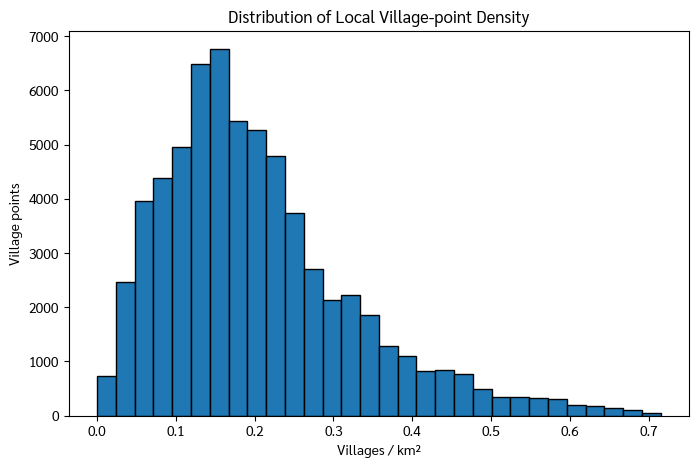

In [6]:
display(
    village_utm[
        "local_density"
    ]
    .describe()
    .to_frame(
        "local_density"
    )
    .round(4)
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    village_utm[
        "local_density"
    ],
    bins=30,
    edgecolor="black"
)

ax.set_title(
    "Distribution of Local Village-point Density"
)

ax.set_xlabel(
    "Villages / km²"
)

ax.set_ylabel(
    "Village points"
)

plt.show()

## 12. Map source points before interpolation

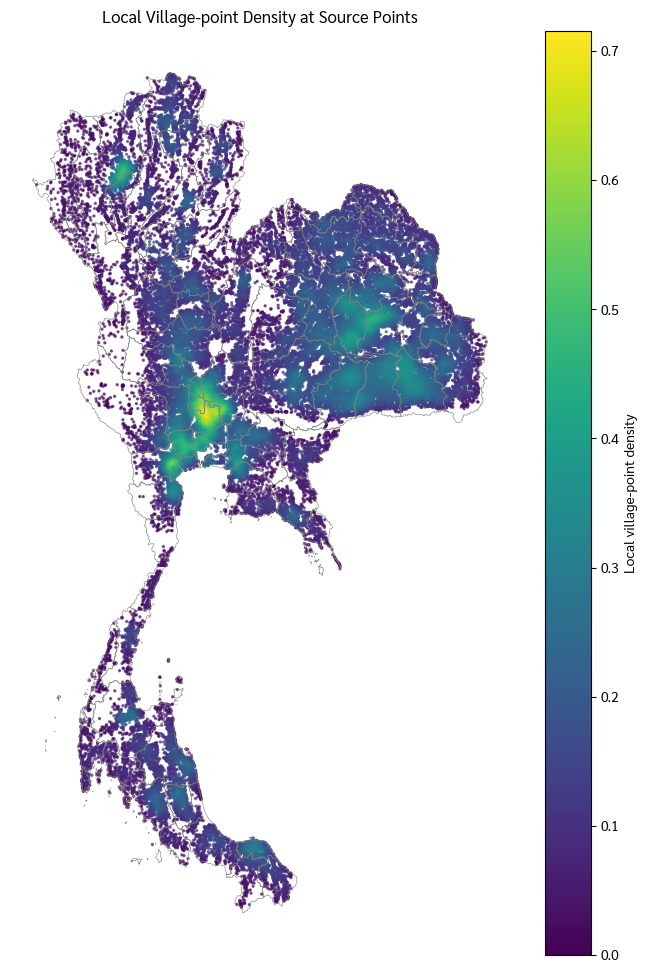

In [7]:
fig, ax = plt.subplots(
    figsize=(9, 12)
)

province_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.4
)

village_utm.plot(
    ax=ax,
    column="local_density",
    cmap="viridis",
    markersize=2,
    alpha=0.6,
    legend=True,
    legend_kwds={
        "label": "Local village-point density"
    }
)

ax.set_title(
    "Local Village-point Density at Source Points"
)

ax.set_axis_off()

plt.show()

### Duplicate coordinates ก่อน interpolation

ข้อมูล point อาจมีหลาย records ที่พิกัดเดียวกัน

เพื่อไม่ให้ interpolation algorithms บางชนิดมีปัญหากับ duplicate coordinates เราจะ aggregate จุดที่พิกัดตรงกัน โดยใช้ค่าเฉลี่ย `local_density`

In [8]:
interp_df = pd.DataFrame({
    "x": village_utm.geometry.x,
    "y": village_utm.geometry.y,
    "local_density": village_utm[
        "local_density"
    ]
})

interp_points = (
    interp_df
    .groupby(
        ["x", "y"],
        as_index=False
    )
    .agg(
        local_density=(
            "local_density",
            "mean"
        ),
        n_records=(
            "local_density",
            "size"
        )
    )
)

interp_xy = interp_points[
    ["x", "y"]
].to_numpy()

interp_z = interp_points[
    "local_density"
].to_numpy()

print(
    "Original records:",
    len(village_utm)
)

print(
    "Unique interpolation locations:",
    len(interp_points)
)

Original records: 65213
Unique interpolation locations: 63659


# Part C — Raster Grid & IDW at 4 Resolutions

## 13. Raster terminology

Raster ประกอบด้วย:

```text
Extent
Rows
Columns
Cell size
Cell center
CRS
NoData
```

ค่าที่เราประมาณจะอยู่ที่ **cell center**

## 14. Resolution ≠ Search Radius

### Cell size

กำหนดความละเอียดของ output raster

### Search radius

กำหนดว่าจุดต้นทางใดมีอิทธิพลต่อ prediction

$$
\boxed{
Raster\ Resolution
\neq
Interpolation\ Neighborhood
}
$$

ในบทนี้ใช้ teaching heuristic:

$$
Search\ Radius
=
2\times Cell\ Size
$$

นี่ **ไม่ใช่ universal optimal rule**

งานวิจัยจริงควรเลือก neighborhood จาก sampling density, process scale และ validation

## 16. IDW

$$
\hat z(x_0)
=
\frac{
\sum_i w_i z_i
}{
\sum_i w_i
}
$$

โดย

$$
w_i=
\frac{1}{d_i^p}
$$

บทนี้ใช้

$$
p=2
$$

```text
ใกล้ → น้ำหนักมาก
ไกล → น้ำหนักน้อย
```

## 15. IDW experiment configuration

In [9]:
GRID_CONFIG = {
    10: 20,
    20: 40,
    50: 100,
    100: 200
}

config_table = pd.DataFrame({
    "cell_km": list(
        GRID_CONFIG.keys()
    ),
    "search_radius_km": list(
        GRID_CONFIG.values()
    )
})

config_table[
    "rule"
] = "radius = 2 × cell size"

display(config_table)

,cell_km,search_radius_km,rule
0,10,20,radius = 2 × cell size
1,20,40,radius = 2 × cell size
2,50,100,radius = 2 × cell size
3,100,200,radius = 2 × cell size


## 17. Common snapped extent

การใช้ extent และ grid origin เดียวกันช่วยให้ 10, 20, 50 และ 100 km grids เปรียบเทียบกันได้เป็นระบบ

In [10]:
xmin, ymin, xmax, ymax = (
    province_utm.total_bounds
)

SNAP_M = 100_000

xmin_s = (
    np.floor(
        xmin / SNAP_M
    )
    * SNAP_M
)

ymin_s = (
    np.floor(
        ymin / SNAP_M
    )
    * SNAP_M
)

xmax_s = (
    np.ceil(
        xmax / SNAP_M
    )
    * SNAP_M
)

ymax_s = (
    np.ceil(
        ymax / SNAP_M
    )
    * SNAP_M
)

print(
    "Snapped extent:",
    xmin_s,
    ymin_s,
    xmax_s,
    ymax_s
)

Snapped extent: 300000.0 600000.0 1300000.0 2300000.0


## 18. Grid-maker function

## 19. IDW function — radius limited

In [11]:
def make_grid(
    cell_km
):
    cell_m = (
        cell_km
        * 1000
    )

    width = int(
        round(
            (xmax_s - xmin_s)
            / cell_m
        )
    )

    height = int(
        round(
            (ymax_s - ymin_s)
            / cell_m
        )
    )

    x_centers = (
        xmin_s
        + cell_m / 2
        + np.arange(width)
        * cell_m
    )

    y_centers = (
        ymax_s
        - cell_m / 2
        - np.arange(height)
        * cell_m
    )

    xx, yy = np.meshgrid(
        x_centers,
        y_centers
    )

    grid_xy = np.column_stack([
        xx.ravel(),
        yy.ravel()
    ])

    transform = from_origin(
        xmin_s,
        ymax_s,
        cell_m,
        cell_m
    )

    return {
        "cell_km": cell_km,
        "cell_m": cell_m,
        "width": width,
        "height": height,
        "xx": xx,
        "yy": yy,
        "xy": grid_xy,
        "transform": transform
    }

# ---------------------------------------------

source_tree = cKDTree(
    interp_xy
)


def idw_predict(
    query_xy,
    search_radius_m,
    power=2
):
    result = np.full(
        len(query_xy),
        np.nan,
        dtype=float
    )

    neighbor_lists = (
        source_tree
        .query_ball_point(
            query_xy,
            r=search_radius_m
        )
    )

    for i, idx in enumerate(
        neighbor_lists
    ):
        if len(idx) == 0:
            continue

        pts = interp_xy[idx]
        vals = interp_z[idx]

        d = np.sqrt(
            (
                (
                    pts
                    - query_xy[i]
                )**2
            ).sum(
                axis=1
            )
        )

        exact = (
            d == 0
        )

        if exact.any():
            result[i] = (
                vals[exact]
                .mean()
            )
            continue

        weights = (
            1.0
            / np.power(
                d,
                power
            )
        )

        result[i] = (
            np.sum(
                weights
                * vals
            )
            / np.sum(weights)
        )

    return result

## 20. Run IDW at 10, 20, 50 and 100 km

In [12]:
idw_results = {}

summary_rows = []

for cell_km, radius_km in (
    GRID_CONFIG.items()
):
    grid = make_grid(
        cell_km
    )

    pred = idw_predict(
        grid["xy"],
        search_radius_m=(
            radius_km
            * 1000
        ),
        power=2
    )

    array = pred.reshape(
        grid["height"],
        grid["width"]
    )

    idw_results[
        cell_km
    ] = {
        **grid,
        "radius_km": radius_km,
        "raw": array
    }

    finite = array[
        np.isfinite(array)
    ]

    summary_rows.append({
        "cell_km": cell_km,
        "radius_km": radius_km,
        "rows": grid["height"],
        "cols": grid["width"],
        "cells": array.size,
        "valid_cells": len(finite),
        "min": (
            finite.min()
            if len(finite)
            else np.nan
        ),
        "max": (
            finite.max()
            if len(finite)
            else np.nan
        ),
        "mean": (
            finite.mean()
            if len(finite)
            else np.nan
        )
    })

raster_summary = pd.DataFrame(
    summary_rows
)

display(
    raster_summary.round(4)
)

,cell_km,radius_km,rows,cols,cells,valid_cells,min,max,mean
0,10,20,170,100,17000,6254,0.0000,0.6783,0.1144
1,20,40,85,50,4250,1882,0.0000,0.6433,0.1115
2,50,100,34,20,680,422,0.0024,0.5176,0.1157
3,100,200,17,10,170,138,0.0087,0.4120,0.1346


## 21. Shared color scale for IDW resolution comparison

ใช้ shared color scale เพื่อให้สีเดียวกันหมายถึงค่าเดียวกันในทุกแผนที่

ใช้ percentile 2–98% เพื่อไม่ให้ extreme cells เพียงเล็กน้อยบีบ contrast ของแผนที่ทั้งหมด

In [13]:
all_idw_values = np.concatenate([
    item["raw"][
        np.isfinite(
            item["raw"]
        )
    ]
    for item in idw_results.values()
])

IDW_VMIN = max(
    0,
    np.nanpercentile(
        all_idw_values,
        2
    )
)

IDW_VMAX = np.nanpercentile(
    all_idw_values,
    98
)

print(
    "Shared IDW scale:",
    IDW_VMIN,
    "to",
    IDW_VMAX
)

Shared IDW scale: 0.005244580547771096 to 0.36362141891894445


## 22. Compare IDW rasters BEFORE Thailand mask

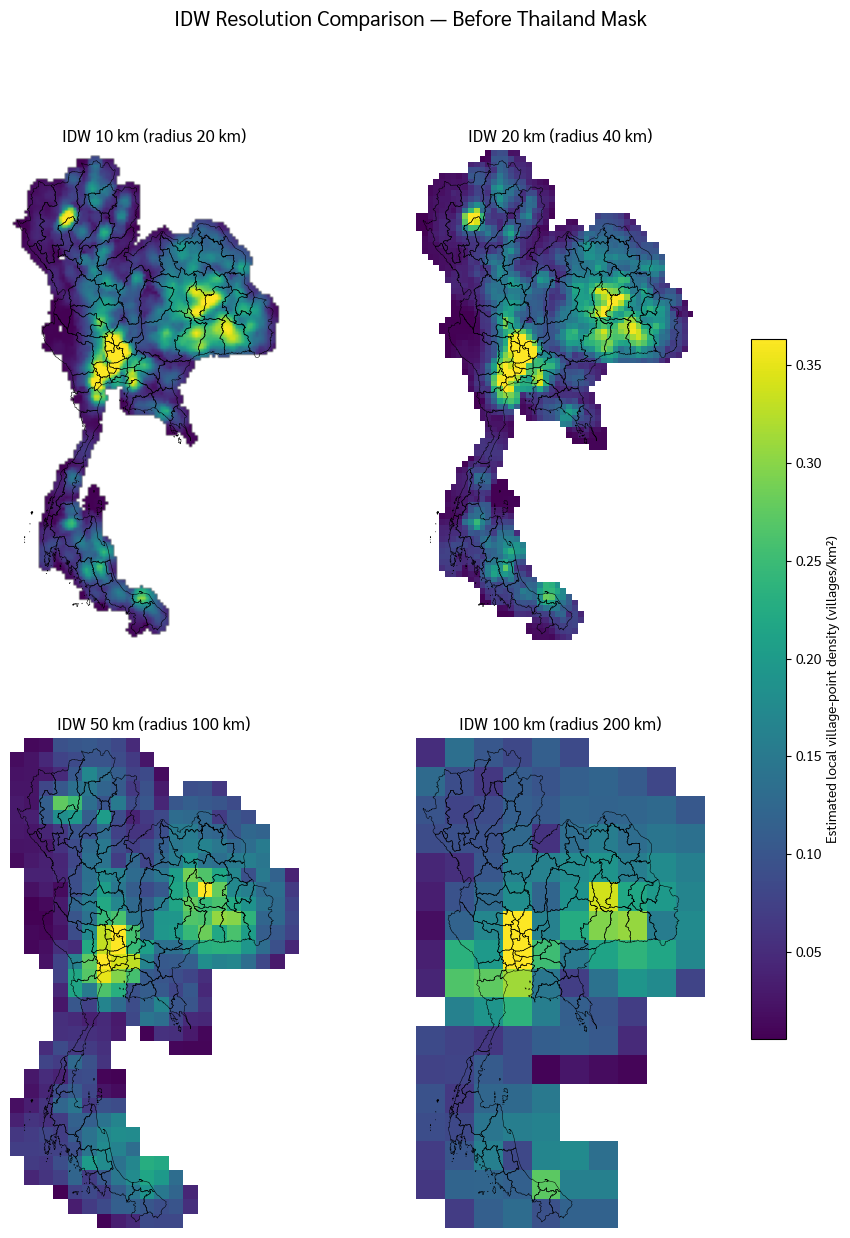

In [14]:
fig_idw_before, axes = plt.subplots(
    2,
    2,
    figsize=(12, 14)
)

for ax, cell_km in zip(
    axes.ravel(),
    GRID_CONFIG.keys()
):
    item = idw_results[
        cell_km
    ]

    im = ax.imshow(
        item["raw"],
        extent=[
            xmin_s,
            xmax_s,
            ymin_s,
            ymax_s
        ],
        origin="upper",
        cmap="viridis",
        vmin=IDW_VMIN,
        vmax=IDW_VMAX
    )

    province_utm.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.35
    )

    ax.set_title(
        f"IDW {cell_km} km "
        f"(radius {item['radius_km']} km)"
    )

    ax.set_axis_off()

cbar = fig_idw_before.colorbar(
    ScalarMappable(
        norm=Normalize(
            IDW_VMIN,
            IDW_VMAX
        ),
        cmap="viridis"
    ),
    ax=axes.ravel().tolist(),
    shrink=0.65
)

cbar.set_label(
    "Estimated local village-point density "
    "(villages/km²)"
)

fig_idw_before.suptitle(
    "IDW Resolution Comparison — Before Thailand Mask",
    fontsize=15,
    fontweight="bold"
)

plt.show()

สังเกตว่า raster เป็น rectangular extent

ประเทศไทยเป็นเพียง boundary ที่ overlay อยู่ด้านบน

ดังนั้น:

\[
Raster\ Extent

eq
Study\ Area
\]

# Part D — Mask Raster to Thailand

## 23. Dissolve ADM1 → Thailand mask

## 24. Mask helper

## 25. Mask all 4 IDW rasters

In [15]:
thailand_mask = (
    province_utm[
        ["geometry"]
    ]
    .dissolve()
    .reset_index(drop=True)
)

thailand_geom = (
    thailand_mask.geometry
    .iloc[0]
)

print(
    "Thailand geometry:",
    thailand_geom.geom_type
)

# ---------------------------------------------

def mask_array_to_geometry(
    array,
    transform,
    geometry
):
    inside = geometry_mask(
        [
            mapping(
                geometry
            )
        ],
        out_shape=array.shape,
        transform=transform,
        invert=True
    )

    return np.where(
        inside,
        array,
        np.nan
    )

# ---------------------------------------------

for cell_km, item in (
    idw_results.items()
):
    item["masked"] = (
        mask_array_to_geometry(
            item["raw"],
            item["transform"],
            thailand_geom
        )
    )

print(
    "Thailand masking complete."
)

Thailand geometry: MultiPolygon
Thailand masking complete.


## 26. Compare IDW rasters AFTER Thailand mask

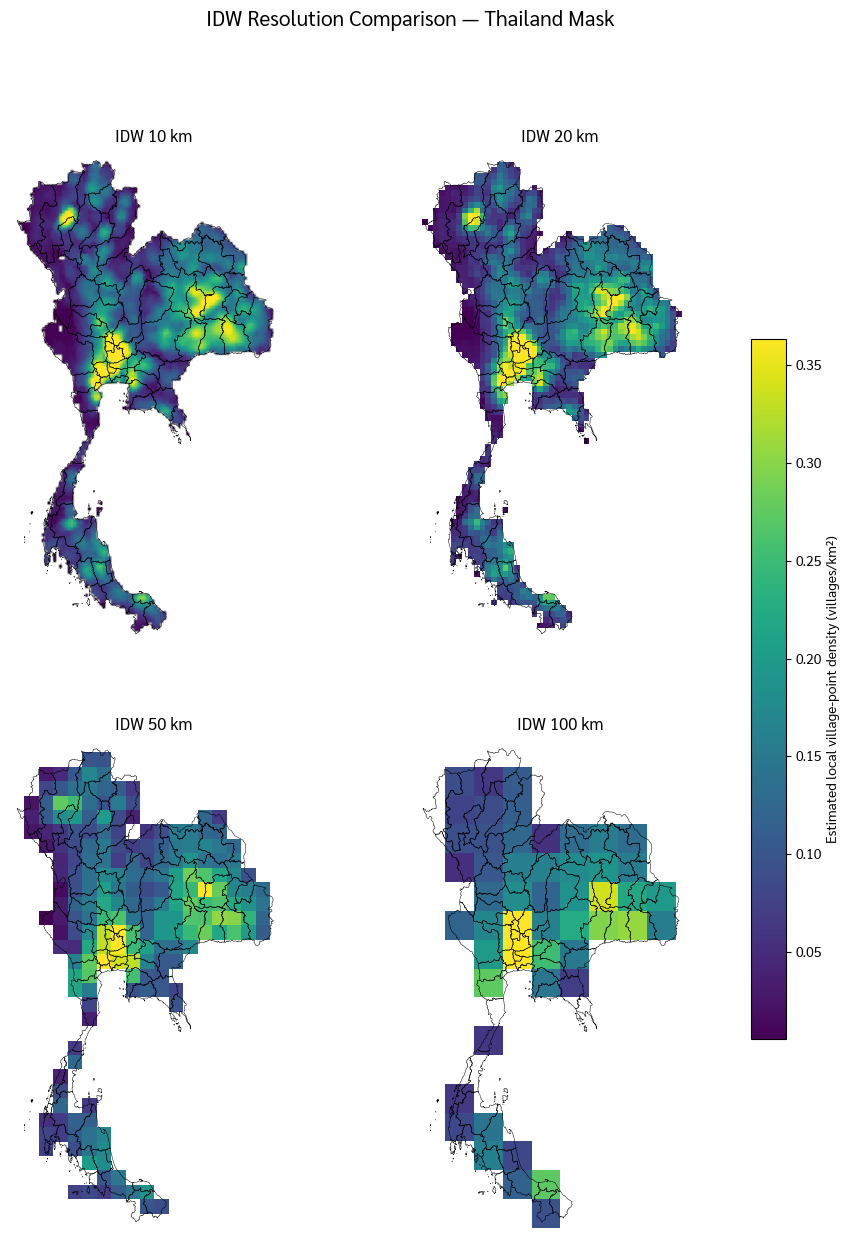

In [16]:
fig_idw_after, axes = plt.subplots(
    2,
    2,
    figsize=(12, 14)
)

for ax, cell_km in zip(
    axes.ravel(),
    GRID_CONFIG.keys()
):
    item = idw_results[
        cell_km
    ]

    ax.imshow(
        item["masked"],
        extent=[
            xmin_s,
            xmax_s,
            ymin_s,
            ymax_s
        ],
        origin="upper",
        cmap="viridis",
        vmin=IDW_VMIN,
        vmax=IDW_VMAX
    )

    province_utm.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.35
    )

    ax.set_title(
        f"IDW {cell_km} km"
    )

    ax.set_axis_off()

cbar = fig_idw_after.colorbar(
    ScalarMappable(
        norm=Normalize(
            IDW_VMIN,
            IDW_VMAX
        ),
        cmap="viridis"
    ),
    ax=axes.ravel().tolist(),
    shrink=0.65
)

cbar.set_label(
    "Estimated local village-point density "
    "(villages/km²)"
)

fig_idw_after.suptitle(
    "IDW Resolution Comparison — Thailand Mask",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## 27. Resolution interpretation

```text
10 km
→ finer local detail

20 km
→ slightly smoother

50 km
→ regional pattern

100 km
→ strong generalization / smoothing
```

แต่

$$
\boxed{
Higher\ resolution
\neq
Automatically\ better
}
$$

Resolution ต้องเหมาะกับ data density, process scale และคำถามวิจัย

# Part E — GeoTIFF & Raster Metadata

## 28. GeoTIFF writer

In [17]:
NODATA = -9999.0


def write_geotiff(
    path,
    array,
    transform,
    crs="EPSG:32647"
):
    out = np.where(
        np.isfinite(array),
        array,
        NODATA
    ).astype(
        "float32"
    )

    with rasterio.open(
        path,
        "w",
        driver="GTiff",
        height=out.shape[0],
        width=out.shape[1],
        count=1,
        dtype="float32",
        crs=crs,
        transform=transform,
        nodata=NODATA,
        compress="deflate"
    ) as dst:
        dst.write(
            out,
            1
        )

# ---------------------------------------------

for cell_km, item in (
    idw_results.items()
):
    write_geotiff(
        RASTER_DIR
        / f"idw_{cell_km}km_raw.tif",
        item["raw"],
        item["transform"]
    )

    write_geotiff(
        RASTER_DIR
        / f"idw_{cell_km}km_thailand.tif",
        item["masked"],
        item["transform"]
    )

print(
    "IDW GeoTIFFs exported."
)

# ---------------------------------------------

sample_raster = (
    RASTER_DIR
    / "idw_50km_thailand.tif"
)

with rasterio.open(
    sample_raster
) as src:
    print(
        "CRS:",
        src.crs
    )

    print(
        "Width × Height:",
        src.width,
        "×",
        src.height
    )

    print(
        "Resolution:",
        src.res
    )

    print(
        "NoData:",
        src.nodata
    )

    print(
        "Transform:",
        src.transform
    )

IDW GeoTIFFs exported.
CRS: EPSG:32647
Width × Height: 20 × 34
Resolution: (50000.0, 50000.0)
NoData: -9999.0
Transform: | 50000.00, 0.00, 300000.00|
| 0.00,-50000.00, 2300000.00|
| 0.00, 0.00, 1.00|


# Part F — Raster → Province Zonal Statistics

## 31. Zonal Statistics

เราเปลี่ยน representation อีกครั้ง:

$$
Point
\rightarrow
Raster
\rightarrow
Province
$$

สำหรับจังหวัด $p$:

$$
\bar z_p
=
\frac{
1
}{
n_p
}
\sum_{i=1}^{n_p}
z_i
$$

ในบทนี้ใช้เพียง:

```text
mean
count
```

`count` สำคัญเพราะ coarse raster อาจมี cell รองรับจังหวัดเล็กเพียงไม่กี่ cell

## 32. Zonal mean + valid-cell count helper

In [18]:
def zonal_mean_count(
    polygons,
    array,
    transform
):
    means = []
    counts = []

    for geom in (
        polygons.geometry
    ):
        inside = geometry_mask(
            [
                mapping(
                    geom
                )
            ],
            out_shape=array.shape,
            transform=transform,
            invert=True
        )

        values = array[
            inside
            & np.isfinite(array)
        ]

        counts.append(
            int(
                len(values)
            )
        )

        means.append(
            float(
                values.mean()
            )
            if len(values) > 0
            else np.nan
        )

    return means, counts

## 33. Run zonal statistics for all 4 resolutions

In [19]:
province_idw_stats = (
    province_utm[
        [
            P_CODE,
            P_NAME,
            "geometry"
        ]
    ]
    .copy()
)

for cell_km, item in (
    idw_results.items()
):
    means, counts = (
        zonal_mean_count(
            province_idw_stats,
            item["masked"],
            item["transform"]
        )
    )

    province_idw_stats[
        f"IDW{cell_km}_mean"
    ] = means

    province_idw_stats[
        f"IDW{cell_km}_count"
    ] = counts

display(
    province_idw_stats[
        [
            P_NAME,
            "IDW10_mean",
            "IDW20_mean",
            "IDW50_mean",
            "IDW100_mean",
            "IDW10_count",
            "IDW100_count"
        ]
    ].head(15)
)

,ADM1_TH,IDW10_mean,IDW20_mean,IDW50_mean,IDW100_mean,IDW10_count,IDW100_count
0,กรุงเทพมหานคร,0.273324,0.313930,0.341070,NaN,18,0
1,สมุทรปราการ,0.195375,0.247472,NaN,NaN,9,0
2,นนทบุรี,0.433643,0.404795,NaN,NaN,5,0
3,ปทุมธานี,0.323151,0.370568,NaN,0.411835,16,1
4,พระนครศรีอยุธยา,0.526251,0.541571,0.517603,NaN,25,0
5,อ่างทอง,0.499894,0.457898,NaN,NaN,10,0
6,ลพบุรี,0.176826,0.181137,0.296929,NaN,64,0
7,สิงห์บุรี,0.401790,0.375013,NaN,0.412040,9,1
8,ชัยนาท,0.214304,0.222255,0.243295,NaN,26,0
9,สระบุรี,0.267564,0.273631,0.257911,0.162037,36,1


## 34. Why raster-cell count matters

จังหวัดที่มี valid cells น้อยมากใน raster 100 km ไม่ควรถูกตีความละเอียดเท่ากับ raster 10 km

นี่คือผลโดยตรงของ **spatial resolution**

In [20]:
count_summary = pd.DataFrame({
    "Resolution_km": [
        10,
        20,
        50,
        100
    ],
    "Min_cells_per_province": [
        province_idw_stats[
            f"IDW{r}_count"
        ].min()
        for r in [
            10,
            20,
            50,
            100
        ]
    ],
    "Median_cells_per_province": [
        province_idw_stats[
            f"IDW{r}_count"
        ].median()
        for r in [
            10,
            20,
            50,
            100
        ]
    ]
})

display(
    count_summary
)

,Resolution_km,Min_cells_per_province,Median_cells_per_province
0,10,5,56.0
1,20,1,14.0
2,50,0,2.0
3,100,0,1.0


## 35. Provincial choropleths — 4 IDW resolutions

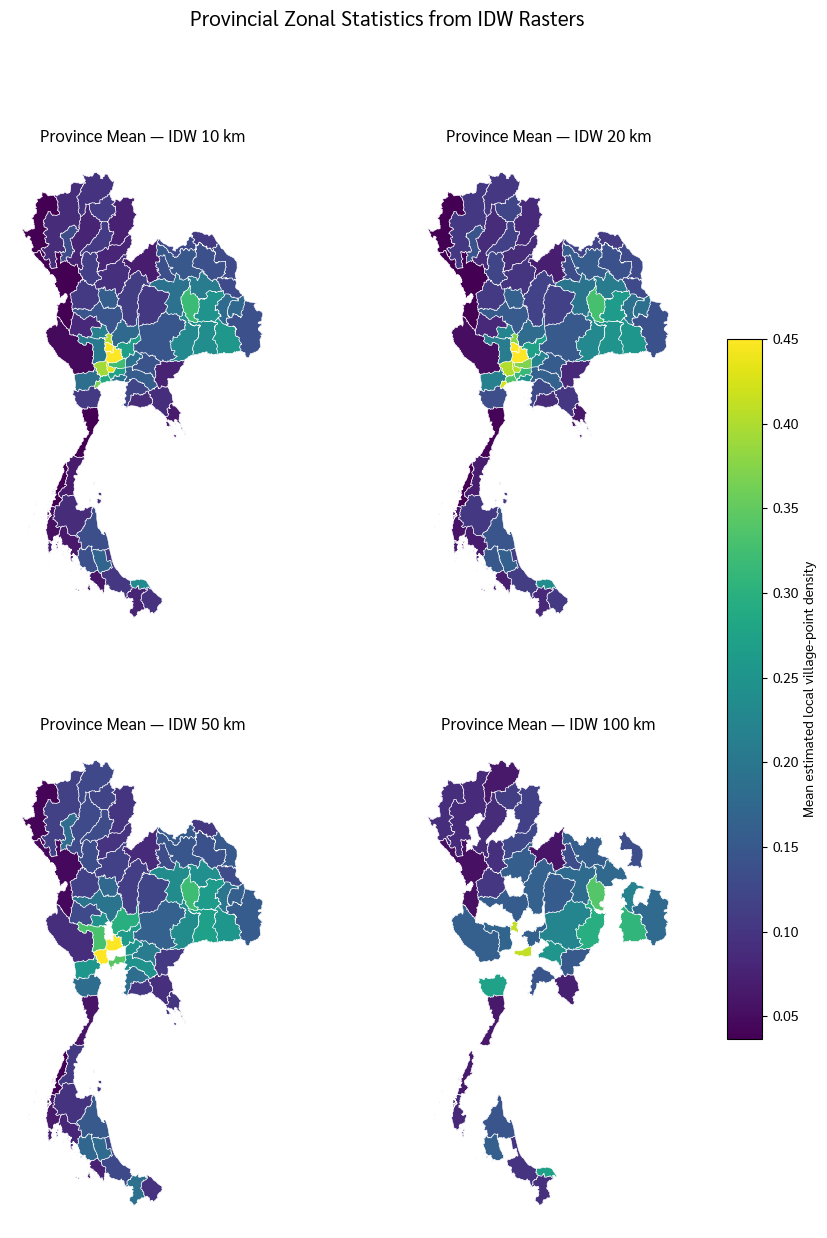

In [21]:
idw_mean_cols = [
    "IDW10_mean",
    "IDW20_mean",
    "IDW50_mean",
    "IDW100_mean"
]

province_values = (
    province_idw_stats[
        idw_mean_cols
    ]
    .to_numpy()
    .ravel()
)

province_values = province_values[
    np.isfinite(
        province_values
    )
]

PROV_IDW_VMIN = max(
    0,
    np.percentile(
        province_values,
        2
    )
)

PROV_IDW_VMAX = np.percentile(
    province_values,
    98
)

fig_province_idw, axes = plt.subplots(
    2,
    2,
    figsize=(12, 14)
)

for ax, cell_km in zip(
    axes.ravel(),
    [10, 20, 50, 100]
):
    province_idw_stats.plot(
        ax=ax,
        column=f"IDW{cell_km}_mean",
        cmap="viridis",
        vmin=PROV_IDW_VMIN,
        vmax=PROV_IDW_VMAX,
        edgecolor="white",
        linewidth=0.4
    )

    ax.set_title(
        f"Province Mean — IDW {cell_km} km"
    )

    ax.set_axis_off()

cbar = fig_province_idw.colorbar(
    ScalarMappable(
        norm=Normalize(
            PROV_IDW_VMIN,
            PROV_IDW_VMAX
        ),
        cmap="viridis"
    ),
    ax=axes.ravel().tolist(),
    shrink=0.65
)

cbar.set_label(
    "Mean estimated local village-point density"
)

fig_province_idw.suptitle(
    "Provincial Zonal Statistics from IDW Rasters",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## 36. Resolution sensitivity at province level

In [22]:
province_rank_compare = (
    province_idw_stats[
        [
            P_NAME,
            "IDW10_mean",
            "IDW20_mean",
            "IDW50_mean",
            "IDW100_mean"
        ]
    ]
    .copy()
)

for r in [
    10,
    20,
    50,
    100
]:
    province_rank_compare[
        f"rank_{r}"
    ] = (
        province_rank_compare[
            f"IDW{r}_mean"
        ]
        .rank(
            ascending=False,
            method="min"
        )
    )

display(
    province_rank_compare
    .sort_values(
        "rank_10"
    )
    .head(15)
)

,ADM1_TH,IDW10_mean,IDW20_mean,IDW50_mean,IDW100_mean,rank_10,rank_20,rank_50,rank_100
4,พระนครศรีอยุธยา,0.526251,0.541571,0.517603,NaN,1.0,1.0,1.0,NaN
5,อ่างทอง,0.499894,0.457898,NaN,NaN,2.0,2.0,NaN,NaN
2,นนทบุรี,0.433643,0.404795,NaN,NaN,3.0,4.0,NaN,NaN
7,สิงห์บุรี,0.401790,0.375013,NaN,0.412040,4.0,6.0,NaN,1.0
58,นครปฐม,0.392761,0.401697,0.469497,NaN,5.0,5.0,2.0,NaN
60,สมุทรสงคราม,0.369091,0.421239,NaN,NaN,6.0,3.0,NaN,NaN
3,ปทุมธานี,0.323151,0.370568,NaN,0.411835,7.0,7.0,NaN,2.0
32,มหาสารคาม,0.318583,0.328507,0.322013,0.339607,8.0,9.0,5.0,3.0
59,สมุทรสาคร,0.286680,0.334451,NaN,NaN,9.0,8.0,NaN,NaN
0,กรุงเทพมหานคร,0.273324,0.313930,0.341070,NaN,10.0,10.0,3.0,NaN


# Part G — Folium: Compare IDW Resolutions

## 37. Prepare compact JSON-safe Province layer

In [23]:
province_web = (
    province_idw_stats[
        [
            P_CODE,
            P_NAME,
            "IDW10_mean",
            "IDW20_mean",
            "IDW50_mean",
            "IDW100_mean",
            "IDW10_count",
            "IDW20_count",
            "IDW50_count",
            "IDW100_count",
            "geometry"
        ]
    ]
    .copy()
    .to_crs(
        "EPSG:4326"
    )
)

province_web[
    P_CODE
] = province_web[
    P_CODE
].astype(str)

province_geojson = json.loads(
    province_web.to_json()
)

json.dumps(
    province_geojson,
    ensure_ascii=False
)

print(
    "Province GeoJSON serialization OK"
)

Province GeoJSON serialization OK


## 38. Create Folium map + shared bins

## 39. Add 4 provincial IDW choropleth layers

## 40. Tooltip + LayerControl

In [24]:
def add_basemap(
    m,
    provider,
    name,
    show=False
):
    folium.TileLayer(
        tiles=provider.build_url(),
        attr=provider.html_attribution,
        name=name,
        overlay=False,
        control=True,
        show=show
    ).add_to(m)


center_ll = (
    province_web.geometry
    .unary_union
    .centroid
)

m_idw = folium.Map(
    location=[
        center_ll.y,
        center_ll.x
    ],
    zoom_start=5,
    tiles=None,
    control_scale=True
)

add_basemap(
    m_idw,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m_idw,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m_idw,
    xyz.Esri.WorldImagery,
    "Esri World Imagery",
    show=False
)

idw_bins = np.linspace(
    PROV_IDW_VMIN,
    PROV_IDW_VMAX,
    6
)

# ---------------------------------------------

for cell_km in [
    10,
    20,
    50,
    100
]:
    field = (
        f"IDW{cell_km}_mean"
    )

    folium.Choropleth(
        geo_data=province_geojson,
        data=province_web[
            [
                P_CODE,
                field
            ]
        ],
        columns=[
            P_CODE,
            field
        ],
        key_on=(
            "feature.properties."
            + P_CODE
        ),
        fill_color="YlGnBu",
        bins=idw_bins,
        fill_opacity=0.65,
        line_opacity=0.25,
        name=(
            f"IDW {cell_km} km "
            "— Province mean"
        ),
        show=(
            cell_km == 50
        )
    ).add_to(
        m_idw
    )

# ---------------------------------------------

folium.GeoJson(
    province_geojson,
    name="Province boundaries + values",
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#444444",
        "weight": 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            P_NAME,
            "IDW10_mean",
            "IDW20_mean",
            "IDW50_mean",
            "IDW100_mean"
        ],
        aliases=[
            "Province:",
            "IDW 10 km:",
            "IDW 20 km:",
            "IDW 50 km:",
            "IDW 100 km:"
        ],
        localize=True
    )
).add_to(
    m_idw
)

folium.LayerControl(
    collapsed=False
).add_to(
    m_idw
)

m_idw

/tmp/ipykernel_485/118124935.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  .unary_union


ValueError: All values are expected to fall into one of the provided bins (or to be Nan). Please check the `bins` parameter and/or your data.

# Part H — Compare Interpolation Methods at 50 km

## 41. Controlled comparison

เพื่อเปรียบเทียบ interpolation methods อย่างเป็นธรรม เราคงที่:

```text
Input variable  = local village-point density
Grid            = 50 km
Extent          = same
Thailand mask   = same
```

แล้วเปลี่ยนเพียง:

```text
Interpolation method
```

$$
\boxed{
Same\ input
+
Same\ grid
+
Same\ mask
+
Different\ method
}
$$

## 42. IDW 50-km baseline

## 43. Thin Plate Spline (TPS)

TPS สร้าง smooth curved surface

ในบทนี้ใช้ `RBFInterpolator` แบบ local neighbors เพื่อให้เหมาะกับ village points จำนวนมาก

> Spline อาจเกิด overshoot และ prediction ติดลบได้

## 44. Second-order Trend Surface

Trend Surface ใช้ global polynomial:

$$
z=
\beta_0
+\beta_1x
+\beta_2y
+\beta_3x^2
+\beta_4xy
+\beta_5y^2
$$

จึงเหมาะกับ broad regional trend มากกว่ารายละเอียดเฉพาะที่

In [25]:
grid50 = idw_results[
    50
]

idw50_raw = (
    grid50["raw"]
    .copy()
)

print(
    "IDW 50-km grid:",
    idw50_raw.shape
)

# ---------------------------------------------

# Scale coordinates to km for numerical stability
points_km = (
    interp_xy
    / 1000.0
)

query50_km = (
    grid50[
        "xy"
    ]
    / 1000.0
)

tps_model = RBFInterpolator(
    points_km,
    interp_z,
    neighbors=min(
        100,
        len(points_km)
    ),
    smoothing=0.05,
    kernel="thin_plate_spline"
)

tps50_raw = (
    tps_model(
        query50_km
    )
    .reshape(
        grid50["height"],
        grid50["width"]
    )
)

IDW 50-km grid: (34, 20)


In [26]:
x = interp_xy[:, 0]
y = interp_xy[:, 1]

x_mean = x.mean()
y_mean = y.mean()

SCALE = 100_000.0

xs = (
    x - x_mean
) / SCALE

ys = (
    y - y_mean
) / SCALE

X = np.column_stack([
    np.ones(
        len(xs)
    ),
    xs,
    ys,
    xs**2,
    xs * ys,
    ys**2
])

beta, *_ = np.linalg.lstsq(
    X,
    interp_z,
    rcond=None
)

qx = (
    grid50[
        "xy"
    ][:, 0]
    - x_mean
) / SCALE

qy = (
    grid50[
        "xy"
    ][:, 1]
    - y_mean
) / SCALE

Xq = np.column_stack([
    np.ones(
        len(qx)
    ),
    qx,
    qy,
    qx**2,
    qx * qy,
    qy**2
])

trend50_raw = (
    Xq
    @ beta
).reshape(
    grid50["height"],
    grid50["width"]
)

## 45. Diagnostics before physical constraint

Target variable คือ density ดังนั้นค่าติดลบไม่มี physical meaning

เราจะ **รายงานก่อน** ว่ามีกี่ negative cells แล้วจึงสร้าง constrained surface:

$$
z^*
=
\max(z,0)
$$

การ constraint ต้องทำอย่างโปร่งใส ไม่ควรแก้ค่าเงียบ ๆ

In [27]:
method_raw = {
    "IDW": idw50_raw,
    "TPS": tps50_raw,
    "Trend": trend50_raw
}

method_diag_rows = []

for method, arr in (
    method_raw.items()
):
    finite = arr[
        np.isfinite(arr)
    ]

    method_diag_rows.append({
        "Method": method,
        "Min": finite.min(),
        "Max": finite.max(),
        "Mean": finite.mean(),
        "Std": finite.std(),
        "Negative_cells": int(
            (
                finite < 0
            ).sum()
        )
    })

method_diagnostics = pd.DataFrame(
    method_diag_rows
)

display(
    method_diagnostics.round(4)
)

,Method,Min,Max,Mean,Std,Negative_cells
0,IDW,0.0024,0.5176,0.1157,0.0792,0
1,TPS,-2.3906,0.5386,-0.2035,0.4593,419
2,Trend,-0.1224,0.2863,0.1749,0.0860,29


## 46. Non-negative constraint + Thailand mask

## 47. Shared method color scale

In [28]:
method_masked = {}

for method, arr in (
    method_raw.items()
):
    constrained = np.maximum(
        arr,
        0
    )

    masked = mask_array_to_geometry(
        constrained,
        grid50[
            "transform"
        ],
        thailand_geom
    )

    method_masked[
        method
    ] = masked

# ---------------------------------------------

method_values = np.concatenate([
    arr[
        np.isfinite(arr)
    ]
    for arr in method_masked.values()
])

METHOD_VMIN = max(
    0,
    np.percentile(
        method_values,
        2
    )
)

METHOD_VMAX = np.percentile(
    method_values,
    98
)

print(
    "Shared method scale:",
    METHOD_VMIN,
    "to",
    METHOD_VMAX
)

Shared method scale: 0.007865778871576332 to 0.3248752280401975


## 48. Compare IDW vs TPS vs Trend at 50 km

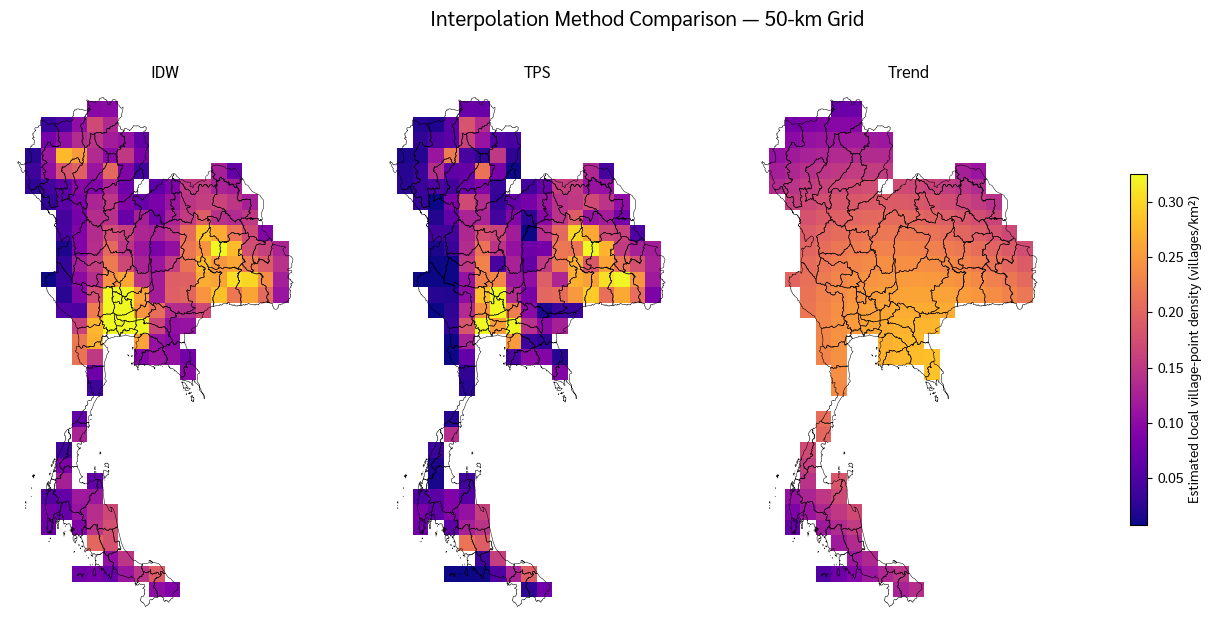

In [29]:
fig_methods, axes = plt.subplots(
    1,
    3,
    figsize=(17, 7)
)

for ax, method in zip(
    axes,
    [
        "IDW",
        "TPS",
        "Trend"
    ]
):
    ax.imshow(
        method_masked[
            method
        ],
        extent=[
            xmin_s,
            xmax_s,
            ymin_s,
            ymax_s
        ],
        origin="upper",
        cmap="plasma",
        vmin=METHOD_VMIN,
        vmax=METHOD_VMAX
    )

    province_utm.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.35
    )

    ax.set_title(
        method
    )

    ax.set_axis_off()

cbar = fig_methods.colorbar(
    ScalarMappable(
        norm=Normalize(
            METHOD_VMIN,
            METHOD_VMAX
        ),
        cmap="plasma"
    ),
    ax=axes.tolist(),
    shrink=0.65
)

cbar.set_label(
    "Estimated local village-point density "
    "(villages/km²)"
)

fig_methods.suptitle(
    "Interpolation Method Comparison — 50-km Grid",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## 49. Interpretation

```text
IDW
→ local distance weighting
→ อาจเห็น local peaks / bull's-eye

TPS
→ smooth curved surface
→ อาจ overshoot

Trend Surface
→ broad regional gradient
→ local variation ถูก smooth มากกว่า
```

แต่:

\[
oxed{
Smoothest\ map

eq
Best\ method
}
\]

และ

\[
oxed{
Most\ detailed\ map

eq
Most\ accurate
}
\]

เรายังไม่มี independent validation ใน core notebook นี้

# Part I — Province Zonal Statistics: IDW vs TPS vs Trend

## 50. Zonal means for all 3 methods

In [30]:
province_method_stats = (
    province_utm[
        [
            P_CODE,
            P_NAME,
            "geometry"
        ]
    ]
    .copy()
)

for method, arr in (
    method_masked.items()
):
    means, counts = (
        zonal_mean_count(
            province_method_stats,
            arr,
            grid50[
                "transform"
            ]
        )
    )

    province_method_stats[
        f"{method}_mean"
    ] = means

    province_method_stats[
        f"{method}_count"
    ] = counts

display(
    province_method_stats[
        [
            P_NAME,
            "IDW_mean",
            "TPS_mean",
            "Trend_mean",
            "IDW_count"
        ]
    ].head(15)
)

,ADM1_TH,IDW_mean,TPS_mean,Trend_mean,IDW_count
0,กรุงเทพมหานคร,0.341070,0.253722,0.260331,1
1,สมุทรปราการ,NaN,NaN,NaN,0
2,นนทบุรี,NaN,NaN,NaN,0
3,ปทุมธานี,NaN,NaN,NaN,0
4,พระนครศรีอยุธยา,0.517603,0.538620,0.256652,1
5,อ่างทอง,NaN,NaN,NaN,0
6,ลพบุรี,0.296929,0.279637,0.248336,3
7,สิงห์บุรี,NaN,NaN,NaN,0
8,ชัยนาท,0.243295,0.227496,0.238927,1
9,สระบุรี,0.257911,0.136494,0.256184,1


## 51. Compare provincial choropleths

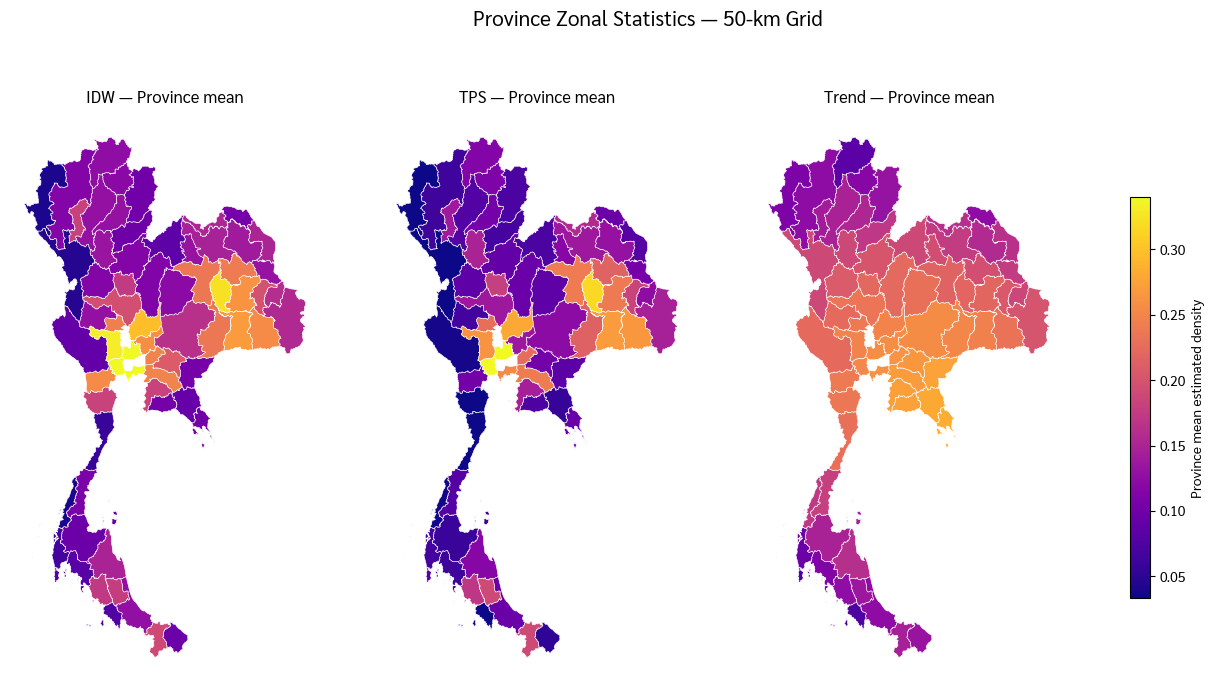

In [31]:
method_cols = [
    "IDW_mean",
    "TPS_mean",
    "Trend_mean"
]

values = (
    province_method_stats[
        method_cols
    ]
    .to_numpy()
    .ravel()
)

values = values[
    np.isfinite(values)
]

PROV_METHOD_VMIN = max(
    0,
    np.percentile(
        values,
        2
    )
)

PROV_METHOD_VMAX = np.percentile(
    values,
    98
)

fig_method_prov, axes = plt.subplots(
    1,
    3,
    figsize=(17, 8)
)

for ax, method in zip(
    axes,
    [
        "IDW",
        "TPS",
        "Trend"
    ]
):
    province_method_stats.plot(
        ax=ax,
        column=f"{method}_mean",
        cmap="plasma",
        vmin=PROV_METHOD_VMIN,
        vmax=PROV_METHOD_VMAX,
        edgecolor="white",
        linewidth=0.4
    )

    ax.set_title(
        f"{method} — Province mean"
    )

    ax.set_axis_off()

cbar = fig_method_prov.colorbar(
    ScalarMappable(
        norm=Normalize(
            PROV_METHOD_VMIN,
            PROV_METHOD_VMAX
        ),
        cmap="plasma"
    ),
    ax=axes.tolist(),
    shrink=0.65
)

cbar.set_label(
    "Province mean estimated density"
)

fig_method_prov.suptitle(
    "Province Zonal Statistics — 50-km Grid",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## 52. Province-level method differences

In [32]:
province_method_compare = (
    province_method_stats[
        [
            P_NAME,
            "IDW_mean",
            "TPS_mean",
            "Trend_mean"
        ]
    ]
    .copy()
)

province_method_compare[
    "TPS_minus_IDW"
] = (
    province_method_compare[
        "TPS_mean"
    ]
    -
    province_method_compare[
        "IDW_mean"
    ]
)

province_method_compare[
    "Trend_minus_IDW"
] = (
    province_method_compare[
        "Trend_mean"
    ]
    -
    province_method_compare[
        "IDW_mean"
    ]
)

display(
    province_method_compare
    .assign(
        max_abs_difference=lambda d:
            d[
                [
                    "TPS_minus_IDW",
                    "Trend_minus_IDW"
                ]
            ]
            .abs()
            .max(
                axis=1
            )
    )
    .sort_values(
        "max_abs_difference",
        ascending=False
    )
    .head(15)
    .round(4)
)

,ADM1_TH,IDW_mean,TPS_mean,Trend_mean,TPS_minus_IDW,Trend_minus_IDW,max_abs_difference
4,พระนครศรีอยุธยา,0.5176,0.5386,0.2567,0.0210,-0.2610,0.2610
58,นครปฐม,0.4695,0.4832,0.2524,0.0137,-0.2171,0.2171
12,จันทบุรี,0.0924,0.0569,0.2812,-0.0355,0.1888,0.1888
13,ตราด,0.0995,0.0926,0.2842,-0.0069,0.1847,0.1847
11,ระยอง,0.1024,0.0737,0.2735,-0.0287,0.1711,0.1711
62,ประจวบคีรีขันธ์,0.0587,0.0236,0.2289,-0.0351,0.1702,0.1702
17,สระแก้ว,0.1048,0.0835,0.2749,-0.0214,0.1701,0.1701
55,ราชบุรี,0.2542,0.1021,0.2392,-0.1522,-0.0150,0.1522
61,เพชรบุรี,0.1829,0.0333,0.2364,-0.1496,0.0535,0.1496
50,ตาก,0.0457,0.0250,0.1882,-0.0207,0.1426,0.1426


# Part J — Folium: Compare Interpolation Methods

## 53. Prepare method web layer

## 54. Create Folium method-comparison map

## 55. Tooltip + LayerControl

In [34]:
# =========================================================
# Prepare compact web layer
# =========================================================

method_web = (
    province_method_stats[
        [
            P_CODE,
            P_NAME,
            "IDW_mean",
            "TPS_mean",
            "Trend_mean",
            "geometry"
        ]
    ]
    .copy()
    .to_crs("EPSG:4326")
)

# Choropleth key should be string
method_web[P_CODE] = (
    method_web[P_CODE]
    .astype(str)
)

# Make sure interpolation results are numeric
method_fields = [
    "IDW_mean",
    "TPS_mean",
    "Trend_mean"
]

for field in method_fields:
    method_web[field] = pd.to_numeric(
        method_web[field],
        errors="coerce"
    )


# =========================================================
# Check actual data range
# =========================================================

method_values = (
    method_web[
        method_fields
    ]
    .to_numpy(dtype=float)
    .ravel()
)

method_values = method_values[
    np.isfinite(method_values)
]

METHOD_MIN = method_values.min()
METHOD_MAX = method_values.max()

print(
    "Actual provincial method range:"
)

print(
    f"Min = {METHOD_MIN:.6f}"
)

print(
    f"Max = {METHOD_MAX:.6f}"
)

print(
    "\nPrevious robust static-map range:"
)

print(
    f"PROV_METHOD_VMIN = "
    f"{PROV_METHOD_VMIN:.6f}"
)

print(
    f"PROV_METHOD_VMAX = "
    f"{PROV_METHOD_VMAX:.6f}"
)


# =========================================================
# Create Folium-safe shared bins
# =========================================================

if np.isclose(
    METHOD_MIN,
    METHOD_MAX
):
    # Defensive case:
    # all province values are effectively identical
    delta = max(
        abs(METHOD_MIN) * 0.01,
        1e-6
    )

    METHOD_MIN -= delta
    METHOD_MAX += delta


method_bins = np.linspace(
    METHOD_MIN,
    METHOD_MAX,
    6
)

# Protect against floating-point edge cases
method_bins[0] = np.nextafter(
    method_bins[0],
    -np.inf
)

method_bins[-1] = np.nextafter(
    method_bins[-1],
    np.inf
)

print(
    "\nFolium shared bins:"
)

print(method_bins)


# =========================================================
# GeoJSON
# =========================================================

method_geojson = json.loads(
    method_web.to_json()
)

# Test JSON serialization
json.dumps(
    method_geojson,
    ensure_ascii=False
)

print(
    "\nMethod GeoJSON serialization OK"
)


# =========================================================
# Map center
# GeoPandas new syntax: union_all()
# =========================================================

center = (
    method_web.geometry
    .union_all()
    .centroid
)


# =========================================================
# Create Folium map
# =========================================================

m_method = folium.Map(
    location=[
        center.y,
        center.x
    ],
    zoom_start=5,
    tiles=None,
    control_scale=True
)

add_basemap(
    m_method,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m_method,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m_method,
    xyz.Esri.WorldImagery,
    "Esri World Imagery",
    show=False
)


# =========================================================
# Add 3 interpolation-method choropleths
# Use exactly the same bins
# =========================================================

for method in [
    "IDW",
    "TPS",
    "Trend"
]:

    field = f"{method}_mean"

    folium.Choropleth(
        geo_data=method_geojson,
        data=method_web[
            [
                P_CODE,
                field
            ]
        ],
        columns=[
            P_CODE,
            field
        ],
        key_on=(
            "feature.properties."
            + P_CODE
        ),
        fill_color="YlOrRd",
        bins=method_bins,
        fill_opacity=0.65,
        line_opacity=0.25,
        nan_fill_color="lightgray",
        nan_fill_opacity=0.4,
        legend_name=(
            "Estimated local village-point "
            "density (villages/km²)"
        ),
        name=(
            f"{method} 50 km "
            "— Province mean"
        ),
        show=(
            method == "IDW"
        )
    ).add_to(
        m_method
    )


# =========================================================
# Transparent Province layer for tooltip
# =========================================================

folium.GeoJson(
    method_geojson,
    name="Province values",
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#444444",
        "weight": 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            P_NAME,
            "IDW_mean",
            "TPS_mean",
            "Trend_mean"
        ],
        aliases=[
            "Province:",
            "IDW mean:",
            "TPS mean:",
            "Trend mean:"
        ],
        localize=True,
        sticky=False
    )
).add_to(
    m_method
)


# =========================================================
# Layer control
# =========================================================

folium.LayerControl(
    collapsed=False
).add_to(
    m_method
)

m_method

Actual provincial method range:
Min = 0.003322
Max = 0.538620

Previous robust static-map range:
PROV_METHOD_VMIN = 0.033674
PROV_METHOD_VMAX = 0.339874

Folium shared bins:
[0.00332159 0.11038127 0.21744096 0.32450064 0.43156033 0.53862001]

Method GeoJSON serialization OK


# Part K — Export

## 56. Export 50-km method rasters

## 57. Export maps

## 58. Export vectors, tables and Folium HTML

## 59. Inspect outputs

In [35]:
for method, arr in (
    method_raw.items()
):
    write_geotiff(
        RASTER_DIR
        / f"{method.lower()}_50km_raw.tif",
        arr,
        grid50[
            "transform"
        ]
    )

for method, arr in (
    method_masked.items()
):
    write_geotiff(
        RASTER_DIR
        / f"{method.lower()}_50km_thailand.tif",
        arr,
        grid50[
            "transform"
        ]
    )

print(
    "Method GeoTIFFs exported."
)

# ---------------------------------------------

fig_idw_before.savefig(
    MAP_DIR
    / "idw_resolution_before_mask_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_idw_after.savefig(
    MAP_DIR
    / "idw_resolution_after_mask_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_province_idw.savefig(
    MAP_DIR
    / "idw_province_zonal_stats_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_methods.savefig(
    MAP_DIR
    / "interpolation_methods_50km_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_method_prov.savefig(
    MAP_DIR
    / "method_zonal_stats_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

print(
    "Publication maps exported."
)

# ---------------------------------------------

# Vector source metric
village_density_gpkg = (
    VECTOR_DIR
    / "village_local_density.gpkg"
)

if village_density_gpkg.exists():
    village_density_gpkg.unlink()

village_utm[
    [
        NAME_FIELD,
        TAMBON_FIELD,
        DISTRICT_FIELD,
        PROVINCE_FIELD,
        "neighbor_20km",
        "local_density",
        "geometry"
    ]
].to_file(
    village_density_gpkg,
    layer="village_local_density",
    driver="GPKG"
)

# Province outputs
idw_gpkg = (
    VECTOR_DIR
    / "province_idw_zonal_stats.gpkg"
)

if idw_gpkg.exists():
    idw_gpkg.unlink()

province_idw_stats.to_file(
    idw_gpkg,
    layer="province_idw_stats",
    driver="GPKG"
)

method_gpkg = (
    VECTOR_DIR
    / "province_method_zonal_stats.gpkg"
)

if method_gpkg.exists():
    method_gpkg.unlink()

province_method_stats.to_file(
    method_gpkg,
    layer="province_method_stats",
    driver="GPKG"
)

# Tables
config_table.to_csv(
    TABLE_DIR
    / "grid_configuration.csv",
    index=False,
    encoding="utf-8-sig"
)

raster_summary.to_csv(
    TABLE_DIR
    / "raster_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

province_idw_stats.drop(
    columns="geometry"
).to_csv(
    TABLE_DIR
    / "province_idw_zonal_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

method_diagnostics.to_csv(
    TABLE_DIR
    / "method_diagnostics.csv",
    index=False,
    encoding="utf-8-sig"
)

province_method_compare.to_csv(
    TABLE_DIR
    / "province_method_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

# Folium
m_idw.save(
    HTML_DIR
    / "idw_resolution_comparison.html"
)

m_method.save(
    HTML_DIR
    / "interpolation_method_comparison.html"
)

print(
    "Vector, table and HTML outputs exported."
)

# ---------------------------------------------

for p in sorted(
    OUTPUT_DIR.rglob("*")
):
    if p.is_file():
        print(
            p.relative_to(
                OUTPUT_DIR
            ),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

Method GeoTIFFs exported.
Publication maps exported.
Vector, table and HTML outputs exported.
html/idw_resolution_comparison.html (4.8 KB)
html/interpolation_method_comparison.html (7,131.6 KB)
maps/idw_province_zonal_stats_300dpi.png (873.1 KB)
maps/idw_resolution_after_mask_300dpi.png (1,115.9 KB)
maps/idw_resolution_before_mask_300dpi.png (1,135.4 KB)
maps/interpolation_methods_50km_300dpi.png (744.4 KB)
maps/method_zonal_stats_300dpi.png (751.5 KB)
rasters/idw_100km_raw.tif (1.0 KB)
rasters/idw_100km_thailand.tif (0.6 KB)
rasters/idw_10km_raw.tif (23.5 KB)
rasters/idw_10km_thailand.tif (19.8 KB)
rasters/idw_20km_raw.tif (7.4 KB)
rasters/idw_20km_thailand.tif (5.4 KB)
rasters/idw_50km_raw.tif (2.0 KB)
rasters/idw_50km_thailand.tif (1.3 KB)
rasters/tps_50km_raw.tif (2.9 KB)
rasters/tps_50km_thailand.tif (1.3 KB)
rasters/trend_50km_raw.tif (2.8 KB)
rasters/trend_50km_thailand.tif (1.3 KB)
tables/grid_configuration.csv (0.2 KB)
tables/method_diagnostics.csv (0.3 KB)
tables/province_idw

# Part L — Concept Check & Exercises

## 60. Concept Check

1. ทำไม village points ที่มีค่า 1 เท่ากันทุกจุดจึงไม่เหมาะกับ IDW?
2. Local village-point density ในบทนี้หมายถึงอะไร?
3. Raster cell size ต่างจาก search radius อย่างไร?
4. ทำไมต้องใช้ shared color scale?
5. Raster extent ต่างจาก Thailand mask อย่างไร?
6. ทำไม zonal-stat `count` จึงสำคัญเมื่อ grid หยาบ?
7. ทำไม method comparison ต้อง fix 50-km grid?
8. IDW, TPS และ Trend Surface มีพฤติกรรมต่างกันอย่างไร?
9. ทำไม negative density prediction ต้องถูกตรวจสอบ?
10. ทำไมดูแผนที่อย่างเดียวจึงยังบอกไม่ได้ว่าวิธี interpolation ใดแม่นที่สุด?

## 61. Exercise 1 — IDW Power

ใช้ grid 50 km และ search radius 100 km

ทดลอง:

$$
p=1,\quad2,\quad3
$$

เปรียบเทียบว่า local peaks และ smoothness เปลี่ยนอย่างไร

## 62. Exercise 2 — Search Radius Sensitivity

ใช้ grid 50 km คงที่ แล้วเปลี่ยน search radius:

```text
50 km
100 km
150 km
```

อธิบายอีกครั้งว่า

```text
Resolution ≠ Search Radius
```

## 63. Exercise 3 — Resolution Comparison

เลือกอย่างน้อย 5 จังหวัด

เปรียบเทียบ:

```text
IDW10_mean
IDW20_mean
IDW50_mean
IDW100_mean
```

แล้วอภิปรายว่าจังหวัดใด sensitive ต่อ raster resolution มากที่สุด

## 64. Exercise 4 — Method Comparison

เลือกอย่างน้อย 5 จังหวัด

เปรียบเทียบ:

```text
IDW_mean
TPS_mean
Trend_mean
```

แล้วอธิบายว่าความแตกต่างสะท้อนพฤติกรรมของ interpolation method อย่างไร

## 65. MSc Challenge — Interpolation Validation

คำถามสำคัญ:

> เราจะรู้ได้อย่างไรว่าวิธีใด “แม่นยำกว่า”?

แนวทาง:

```text
Training points
↓
Fit interpolation
↓
Validation points
↓
Compare observed vs predicted
```

Metrics:

$$
MAE
=
\frac{1}{n}
\sum_i
|y_i-\hat y_i|
$$

$$
RMSE
=
\sqrt{
\frac{1}{n}
\sum_i
(y_i-\hat y_i)^2
}
$$

และ Bias

งาน spatial data ควรระวังว่า random train/test split อาจ optimistic เพราะ spatial autocorrelation

ระดับสูงขึ้นควรใช้ **spatial/block cross-validation**

# Summary

Notebook 09 แสดงการเปลี่ยน representation ของข้อมูล:

$$
\boxed{
Village\ Point
\rightarrow
Local\ Density
\rightarrow
Interpolation
\rightarrow
Raster
\rightarrow
Mask
\rightarrow
Zonal\ Statistics
}
$$

Experiment 1:

$$
IDW:
10,\ 20,\ 50,\ 100\ km
$$

เพื่อเรียนรู้ผลของ **resolution + interpolation neighborhood**

Experiment 2:

$$
IDW
\quad vs \quad
TPS
\quad vs \quad
Trend
$$

บน grid เดียวกัน 50 km เพื่อเปรียบเทียบ **method behavior**

สิ่งที่ต้องจำ:

> **Point location alone is not an interpolated variable**

> **Cell size ≠ Search radius**

> **Higher resolution ≠ automatically better**

> **Shared color scale is required for fair visual comparison**

> **Point → Raster → Polygon is a valid GIS workflow**

> **Smoothest map ≠ best interpolation method**

> **Accuracy requires validation, not visual preference**